# Tech Challenge - Pipeline Completo de Atrasos de Voos

Este notebook consolida o pipeline do projeto, indo do entendimento inicial dos dados até a modelagem supervisionada, a abordagem não supervisionada e as conclusões finais.

Nas aulas, o fluxo foi apresentado como uma sequência lógica: entender a base, tratar os dados, explorar padrões, modelar e interpretar os resultados. Vou seguir exatamente essa linha aqui, eliminando repetições e mantendo apenas o que é mais relevante para a entrega e para a apresentação.

## 1. Importação e Carga dos Dados

Para essa entrega vou focar na base `flights.csv`, que concentra todas as informações operacionais dos voos. Começo fazendo uma visão descritiva sobre o tipo da estrutura e da qualidade desses dados (como o volume de nulos) antes de partir para a montagem dos modelos.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, silhouette_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='Set2')

df_flights = pd.read_csv('./data/flights.csv', low_memory=False)

print(f'Linhas: {df_flights.shape[0]:,}')
print(f'Colunas: {df_flights.shape[1]}')
display(df_flights.head())

Linhas: 5,819,079
Colunas: 31


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Entendimento Inicial da Base

Primeira etapa, entender o que existe na tabela. Aqui, o objetivo é ter uma visão geral sobre:
- tamanho da base;
- tipos de variáveis;
- estatísticas descritivas básicas;
- volume de valores ausentes.

In [17]:
# Colunas e tipos de dados
print('======= Colunas e Tipos de Dados =======\n')
df_flights.info()

# Estatísticas descritivas. Quantidade de valores únicos, média, desvio padrão, mínimo, máximo e quartis.
print('\n======= Estatísticas Descritivas =======')
display(df_flights.describe(include='all').T.head(30))

# Top 10 colunas com mais valores faltantes
print('\n======= Valores Faltantes/Nulos =======')
missing_df = (
    df_flights.isna()
    .sum()
    .sort_values(ascending=False)
    .rename('missing_count')
    .reset_index()
    .rename(columns={'index': 'column'})
)
missing_df['missing_pct'] = (missing_df['missing_count'] / len(df_flights) * 100).round(2)

display(missing_df.head(17))

======= Colunas e Tipos de Dados =======

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       str    
 8   DESTINATION_AIRPORT  str    
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  D

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,NaN,NaN,NaN,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,NaN,NaN,NaN,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,NaN,NaN,NaN,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
AIRLINE,5819079,14,WN,1261855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,5819079.0,NaN,NaN,NaN,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
TAIL_NUMBER,5804358,4897,N480HA,3768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,5819079,628,ATL,346836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,5819079,629,ATL,346904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,5819079.0,NaN,NaN,NaN,1329.60247,483.751821,1.0,917.0,1325.0,1730.0,2359.0



======= Valores Faltantes/Nulos =======


,column,missing_count,missing_pct
0,CANCELLATION_REASON,5729195,98.46
1,LATE_AIRCRAFT_DELAY,4755640,81.72
2,WEATHER_DELAY,4755640,81.72
3,AIRLINE_DELAY,4755640,81.72
4,AIR_SYSTEM_DELAY,4755640,81.72
5,SECURITY_DELAY,4755640,81.72
6,ELAPSED_TIME,105071,1.81
7,AIR_TIME,105071,1.81
8,ARRIVAL_DELAY,105071,1.81
9,WHEELS_ON,92513,1.59


### Leitura Inicial

O que mais chama atenção na qualidade dos dados é que a maior parte dos nulos aparece em colunas ligadas a motivos de atraso ou cancelamento. Faz sentido tantos nulos já que a maioria dos voos não sofre atrasos ou cancelamentos, então essas colunas só vão ter valores preenchidos quando houver um evento de atraso ou cancelamento.

Como o foco do projeto é previsão e exploração de padrões, essas colunas `não` vão entrar como explicação do futuro na modelagem supervisionada.

## 3. Base Analítica e Definição do Alvo

Para a parte supervisionada, o problema será de **classificação**: prever se o voo chegará atrasado.

O alvo será:
- `1` se `ARRIVAL_DELAY > 0`;
- `0` caso contrário.

Também mantenho apenas voos realizados (sem cancelamento e sem desvio), para comparar situações equivalentes.

In [18]:
# Filtra voos que foram realmente realizados (não cancelados nem desviados)
df_analysis = df_flights.loc[
    (df_flights['CANCELLED'] == 0) &
    (df_flights['DIVERTED'] == 0)
] .copy()

# Converte horários planejados (HHMM) para minutos do dia (0 a 1439)
df_analysis['DEP_MIN_OF_DAY'] = ((df_analysis['SCHEDULED_DEPARTURE'] // 100) * 60 + (df_analysis['SCHEDULED_DEPARTURE'] % 100)).astype('Int64')
df_analysis['ARR_MIN_OF_DAY'] = ((df_analysis['SCHEDULED_ARRIVAL'] // 100) * 60 + (df_analysis['SCHEDULED_ARRIVAL'] % 100)).astype('Int64')

# Alvo da classificação: atraso de chegada > 0 minuto
df_analysis['TARGET_DELAY'] = (df_analysis['ARRIVAL_DELAY'] > 0).astype(int)

print(f'Base analítica: {len(df_analysis):,} voos')
print(f'Taxa de voos com atraso (>0 min): {df_analysis["TARGET_DELAY"].mean():.2%}')

Base analítica: 5,714,008 voos
Taxa de voos com atraso (>0 min): 36.52%


## 4. EDA Essencial

Nesta etapa, foco apenas no que é útil para guiar os modelos:
- estatísticas descritivas de atraso;
- colunas com maior volume de nulos;
- distribuição de `ARRIVAL_DELAY`;
- taxa de atraso por companhia e por mês.

Resumo descritivo do campo ARRIVAL_DELAY (minutos):


,valor
count,5714008.00
mean,4.41
std,39.27
min,-87.00
25%,-13.00
50%,-5.00
75%,8.00
max,1971.00


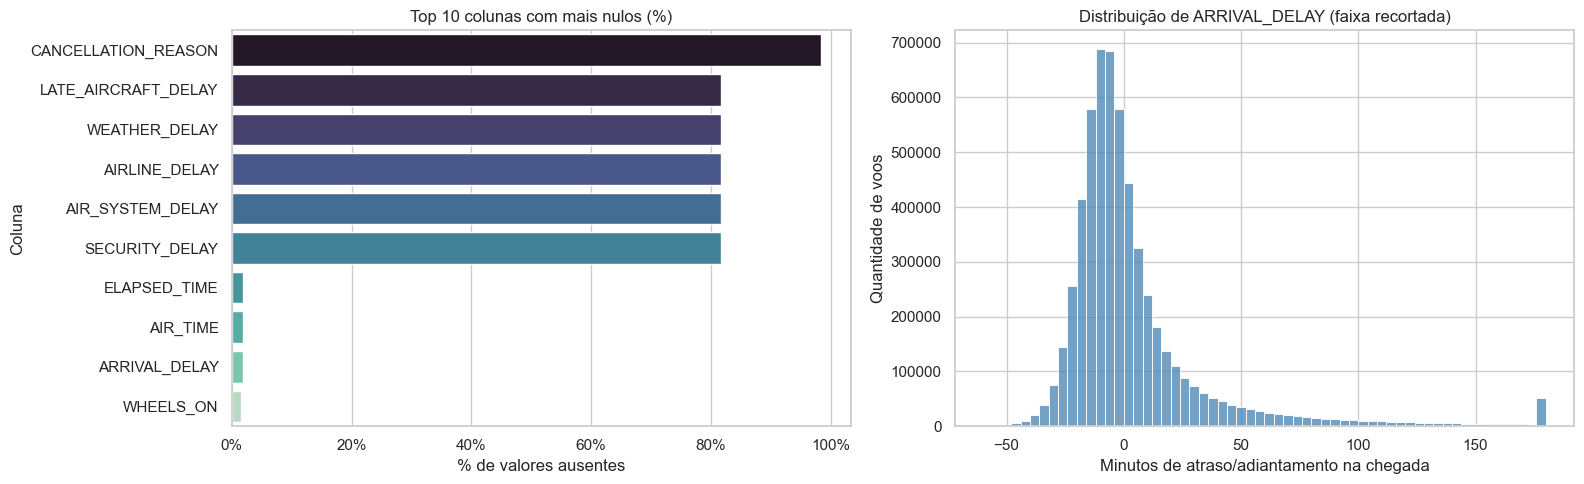

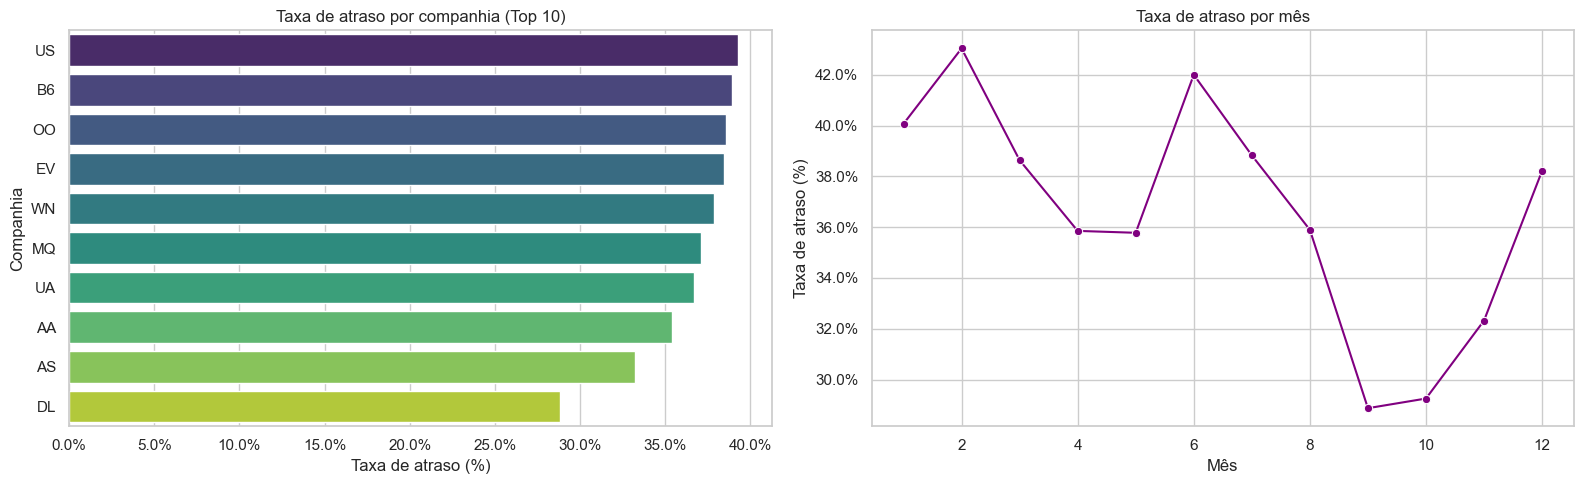

In [19]:
import matplotlib.ticker as mtick

# Top 10 colunas com mais nulos (ordem decrescente para leitura direta)
missing_top = missing_df.nlargest(10, 'missing_pct').sort_values('missing_pct', ascending=False)

# Estatísticas descritivas da variável de atraso
delay_stats = df_analysis['ARRIVAL_DELAY'].describe().round(2)

# Resumos de atraso por companhia e por mês
airline_summary = (
    df_analysis.groupby('AIRLINE')
    .agg(total_voos=('AIRLINE', 'size'), taxa_atraso=('TARGET_DELAY', 'mean'))
    .sort_values('total_voos', ascending=False)
    .head(10)
    .sort_values('taxa_atraso', ascending=False)
    .reset_index()
)

month_summary = (
    df_analysis.groupby('MONTH')
    .agg(taxa_atraso=('TARGET_DELAY', 'mean'))
    .reset_index()
)

print('Resumo descritivo do campo ARRIVAL_DELAY (minutos):')
display(delay_stats.to_frame(name='valor'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=missing_top, x='missing_pct', y='column', ax=axes[0], palette='mako')
axes[0].set_title('Top 10 colunas com mais nulos (%)')
axes[0].set_xlabel('% de valores ausentes')
axes[0].set_ylabel('Coluna')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

sns.histplot(df_analysis['ARRIVAL_DELAY'].clip(-60, 180), bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Distribuição de ARRIVAL_DELAY (faixa recortada)')
axes[1].set_xlabel('Minutos de atraso/adiantamento na chegada')
axes[1].set_ylabel('Quantidade de voos')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=airline_summary, x='taxa_atraso', y='AIRLINE', ax=axes[0], palette='viridis')
axes[0].set_title('Taxa de atraso por companhia (Top 10)')
axes[0].set_xlabel('Taxa de atraso (%)')
axes[0].set_ylabel('Companhia')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

sns.lineplot(data=month_summary, x='MONTH', y='taxa_atraso', marker='o', ax=axes[1], color='purple')
axes[1].set_title('Taxa de atraso por mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Taxa de atraso (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.show()

### Leitura do EDA

Os pontos principais:
- `ARRIVAL_DELAY` é assimétrico, com muitos voos perto do horário e alguns atrasos extremos.
- As maiores taxas de nulos estão em colunas de motivo de atraso/cancelamento, coerentes com preenchimento pós-evento.
- Há diferença de taxa de atraso entre companhias.
- Existe sazonalidade por mês, indicando que o risco de atraso varia ao longo do ano.

## 5. Preparação para a Modelagem Supervisionada

Para manter o pipeline enxuto, vou usar apenas variáveis disponíveis antes do voo e seguir com divisão treino/teste.

Variáveis usadas:
- `MONTH`, `DAY`, `DAY_OF_WEEK`
- `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`
- `DISTANCE`, `SCHEDULED_TIME`, `DEP_MIN_OF_DAY`, `ARR_MIN_OF_DAY`

## 6. Modelagem Supervisionada - Classificação XGBoost

Para atender ao requisito para modelagem supervisionada, vou usar **apenas um modelo de classificação**: **XGBoost**.

,Modelo,Accuracy,Precision_atraso,Recall_atraso,F1_atraso
0,XGBoost,0.6408,0.5067,0.6265,0.5603


<Figure size 700x500 with 0 Axes>

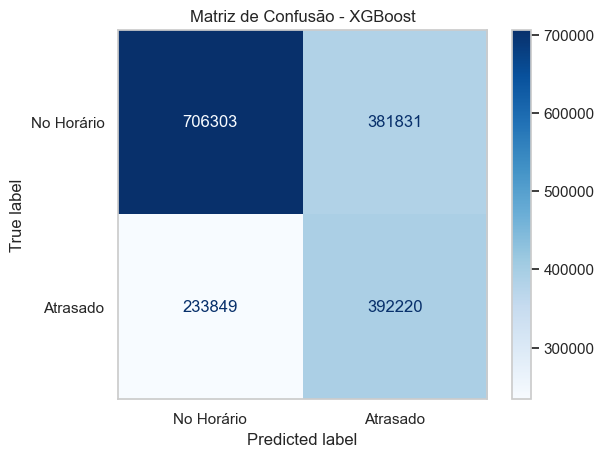

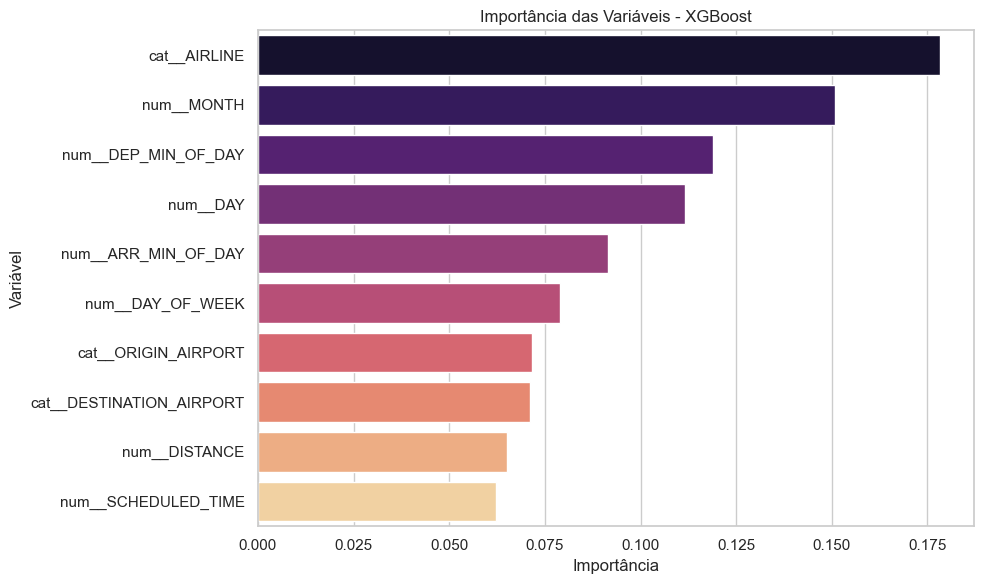

,feature,importance
0,cat__AIRLINE,0.178246
1,num__MONTH,0.150790
2,num__DEP_MIN_OF_DAY,0.119018
3,num__DAY,0.111598
4,num__ARR_MIN_OF_DAY,0.091605
5,num__DAY_OF_WEEK,0.078912
6,cat__ORIGIN_AIRPORT,0.071646
7,cat__DESTINATION_AIRPORT,0.071036
8,num__DISTANCE,0.064988
9,num__SCHEDULED_TIME,0.062161


In [20]:
features_sup = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'DISTANCE', 'SCHEDULED_TIME', 'DEP_MIN_OF_DAY', 'ARR_MIN_OF_DAY'
]

X = df_analysis[features_sup].copy()

# Alvo binário: 1 se atraso > 0, 0 caso contrário
y = df_analysis['TARGET_DELAY'].copy()

categorical_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
numeric_features = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'DISTANCE', 'SCHEDULED_TIME', 'DEP_MIN_OF_DAY', 'ARR_MIN_OF_DAY']

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), categorical_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Amostra estratificada do treino para reduzir custo computacional sem mudar a lógica do modelo
X_train_xgb, _, y_train_xgb, _ = train_test_split(
    X_train, y_train,
    train_size=0.30,
    random_state=42,
    stratify=y_train
)

# Teste com a base toda para verificar ganho de performance (deve ser maior, mas demora mais)
# X_train_xgb = X_train
# y_train_xgb = y_train

def evaluate_binary_model(y_true, y_pred):
    return pd.DataFrame([
        {
            'Modelo': 'XGBoost',
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision_atraso': precision_score(y_true, y_pred, zero_division=0),
            'Recall_atraso': recall_score(y_true, y_pred, zero_division=0),
            'F1_atraso': f1_score(y_true, y_pred, zero_division=0)
        }
    ]).round(4)

scale_pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('model', XGBClassifier(
        n_estimators=150,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        device='cuda',
        eval_metric='logloss',
        random_state=42
    ))
])

pipeline_xgb.fit(X_train_xgb, y_train_xgb)
y_pred_xgb = pipeline_xgb.predict(X_test)

display(evaluate_binary_model(y_test, y_pred_xgb))

plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['No Horário', 'Atrasado'],
    cmap='Blues',
    values_format='d'
 )
plt.title('Matriz de Confusão - XGBoost')
plt.grid(False)
plt.show()

# Importância das variáveis
xgb_model = pipeline_xgb.named_steps['model']
feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': xgb_model.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='magma')
plt.title('Importância das Variáveis - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

display(feature_importance_df.head(15))

### Leitura da Modelagem Supervisionada

Usei uma amostra estratificada de 30% do treino para reduzir o custo computacional, mantendo a lógica do modelo. O modelo foi treinado e avaliado usando as métricas de classificação binária.

A leitura fica:
- A matriz de confusão mostra os acertos e erros por classe ("No Horário" e "Atrasado");
- Accuracy de `0,6408` indica 64,08% de acerto geral;
- Precision de `0,5067` mostra que 50,67% dos voos previstos como atrasados realmente atrasaram;
- Recall de `0,6265` indica que o modelo encontrou 62,65% dos atrasos reais;
- F1 de `0,5603` resume o equilíbrio entre essas duas métricas.

`Precision`, `recall` e `F1_atraso` são mais informativos do que a accuracy em bases desbalanceadas, porque representam melhor o desempenho do modelo na identificação da classe de atraso.

Fiz uma experimentação, rodando o modelo com toda a base, e não uma amostra, e a diferença foi irrelevante. O que indica que a amostra estratificada de 30% foi suficiente para capturar os padrões sem perda de performance, além de reduzir significativamente o tempo de treinamento.

## 7. Modelagem Não Supervisionada

Para a parte não supervisionada, vou agrupar **aeroportos de origem** com base em seu perfil operacional. Em vez de olhar voo a voo, cada linha da base passa a representar um aeroporto.

As variáveis usadas para construir esse perfil serão:
- volume de voos;
- atraso médio de saída em voos realizados;
- taxa de voos com atraso relevante de saída;
- taxa de cancelamento.

Vou usar a combinação entre **K-Means** e **PCA** para analisar os dados.

In [21]:
# Agrupa por aeroporto de origem e calcula indicadores simples de performance
airport_profiles = df_flights[['ORIGIN_AIRPORT', 'DEPARTURE_DELAY', 'CANCELLED']].copy()

airport_profiles['ORIGIN_AIRPORT'] = airport_profiles['ORIGIN_AIRPORT'].astype(str)
airport_profiles['DEPARTURE_DELAY'] = pd.to_numeric(airport_profiles['DEPARTURE_DELAY'], errors='coerce')
airport_profiles['CANCELLED'] = pd.to_numeric(airport_profiles['CANCELLED'], errors='coerce').fillna(0).astype(int)

airport_profiles['completed_flight'] = (airport_profiles['CANCELLED'] == 0).astype(int)
airport_profiles['valid_departure_delay'] = airport_profiles['DEPARTURE_DELAY'].where(airport_profiles['CANCELLED'] == 0)
airport_profiles['is_departure_delayed'] = (
    (airport_profiles['CANCELLED'] == 0) &
    (airport_profiles['DEPARTURE_DELAY'] > 15)
).astype(int)

airport_profiles = airport_profiles.groupby('ORIGIN_AIRPORT').agg(
    total_flights=('ORIGIN_AIRPORT', 'size'),
    completed_flights=('completed_flight', 'sum'),
    avg_departure_delay=('valid_departure_delay', 'mean'),
    delayed_flights=('is_departure_delayed', 'sum'),
    cancel_rate=('CANCELLED', 'mean')
).reset_index()

airport_profiles['delay_rate'] = airport_profiles['delayed_flights'] / airport_profiles['completed_flights']

airport_profiles = airport_profiles[
    (airport_profiles['total_flights'] >= 500) &
    (airport_profiles['completed_flights'] > 0)
].copy()

airport_profiles = airport_profiles.dropna(subset=['avg_departure_delay', 'delay_rate', 'cancel_rate'])

features_unsup = ['total_flights', 'avg_departure_delay', 'delay_rate', 'cancel_rate']
X_unsup = airport_profiles[features_unsup].copy()
X_unsup_scaled = StandardScaler().fit_transform(X_unsup)

metricas_k = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_unsup_scaled)
    metricas_k.append({
        'k': k,
        'inercia': kmeans.inertia_,
        'silhueta': silhouette_score(X_unsup_scaled, labels)
    })

metricas_k = pd.DataFrame(metricas_k)
best_k = int(metricas_k.loc[metricas_k['silhueta'].idxmax(), 'k'])

# Treina o modelo KMeans final com o número ideal de clusters e atribui os rótulos aos perfis de aeroportos
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
airport_profiles['Cluster'] = kmeans_final.fit_predict(X_unsup_scaled).astype(str)

# E aqui aplicamos o PCA pra reduzir a dimencionalidade para visualização dos clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsup_scaled)

# Variância explicada pelos dois componentes principais. Indica quanto da informação original foi preservada na redução de dimensionalidade.
variancia_total = pca.explained_variance_ratio_.sum() * 100

cluster_summary = airport_profiles.groupby('Cluster').agg(
    Qtd_Aeroportos=('ORIGIN_AIRPORT', 'count'),
    Mediana_Total_Voos=('total_flights', 'median'),
    Mediana_Atraso_Saida=('avg_departure_delay', 'median'),
    Mediana_Taxa_Atraso=('delay_rate', 'median'),
    Mediana_Taxa_Cancelamento=('cancel_rate', 'median')
).reset_index()

metricas_k, cluster_summary.round(4)

(   k      inercia  silhueta
 0  2  1028.222479  0.365405
 1  3   724.168545  0.400617
 2  4   564.227465  0.391990
 3  5   483.546213  0.327494
 4  6   414.516865  0.339600
 5  7   358.122284  0.315862
 6  8   318.259289  0.314856,
   Cluster  Qtd_Aeroportos  Mediana_Total_Voos  Mediana_Atraso_Saida  \
 0       0             208              3567.0                7.8981   
 1       1             169              1714.0                3.7616   
 2       2              27            107847.0               11.1723   
 
    Mediana_Taxa_Atraso  Mediana_Taxa_Cancelamento  
 0               0.1545                     0.0240  
 1               0.1069                     0.0051  
 2               0.2019                     0.0117  )

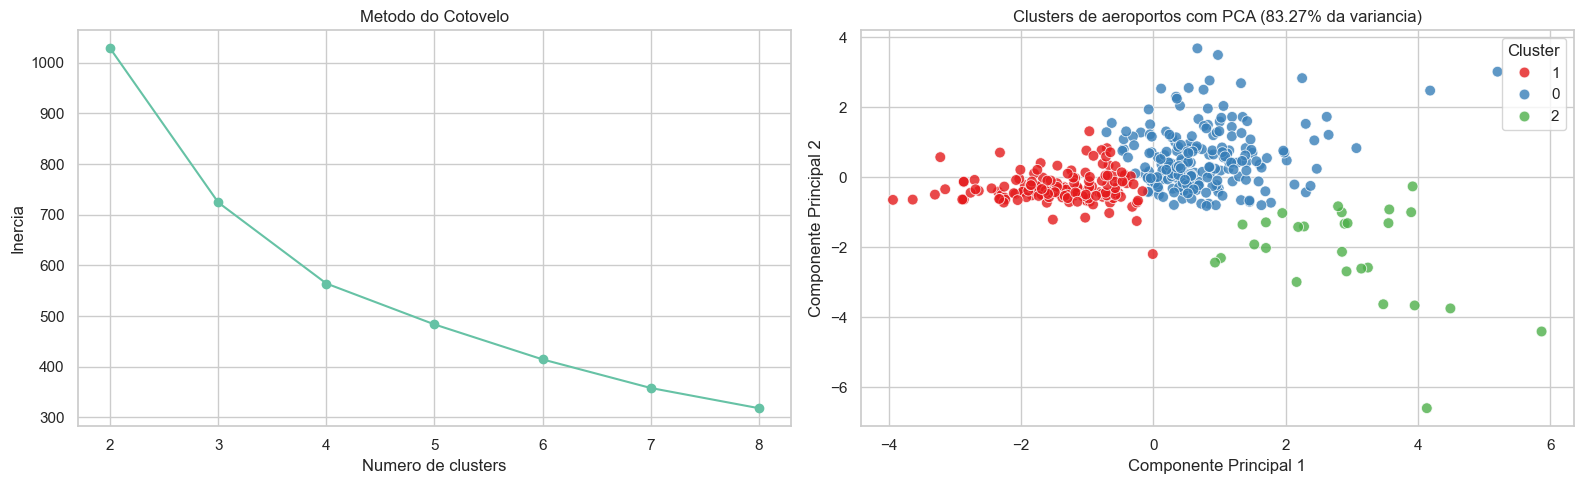

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(metricas_k['k'], metricas_k['inercia'], marker='o')
axes[0].set_title('Metodo do Cotovelo')
axes[0].set_xlabel('Numero de clusters')
axes[0].set_ylabel('Inercia')

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=airport_profiles['Cluster'],
    palette='Set1',
    s=60,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title(f'Clusters de aeroportos com PCA ({variancia_total:.2f}% da variancia)')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

### Leitura da Modelagem Não Supervisionada

A clusterização mantém o requisito mínimo com clareza:
- aeroportos são agrupados por perfil operacional (volume, atraso médio, taxa de atraso e cancelamento);
- `K-Means` cria grupos com comportamentos distintos;
- `PCA` permite visualizar os grupos em 2 dimensões para facilitar a interpretação graficamente.

Esse bloco complementa a classificação ao mostrar padrões estruturais do sistema, não apenas previsão voo a voo.

## 8. Conclusões Finais e Apresentação Crítica

Este trabalho mostra que, mesmo com um pipeline enxuto, é possível extrair valor analítico e preditivo da base de voos.

**Síntese dos achados**
- O EDA confirmou padrão assimétrico em `ARRIVAL_DELAY`, concentração de nulos em campos pós-evento e variação de atraso por companhia e por mês.
- Na classificação, foi adotado **um único modelo** (XGBoost), em linha com o requisito mínimo.
- O XGBoost atingiu: **Accuracy = 0.6407**, **Precision_atraso = 0.5065**, **Recall_atraso = 0.6270** e **F1_atraso = 0.5604**.
- Na análise não supervisionada, o K-Means indicou melhor separação em `k=3` (silhueta ~0.4006), e o PCA preservou cerca de **83.27%** da variância nas duas componentes.

**Leitura crítica (o que os resultados significam)**
- O modelo identifica uma parcela relevante dos voos atrasados (`recall`), mas ainda com precisão moderada (`precision`), o que implica trade-off entre captar atrasos e gerar alarmes falsos.
- O desempenho é útil para apoio à decisão operacional, mas ainda não caracteriza um sistema de alta confiabilidade para automação sem supervisão humana.
- Como não houve comparação entre múltiplos classificadores nesta versão, a conclusão supervisionada deve ser lida como desempenho absoluto do XGBoost neste recorte, e não como “melhor modelo possível”.

**Limitações do estudo**
- O recorte usa apenas as variáveis presentes no dataset e uma formulação binária de atraso (`> 0`), que simplifica a severidade real do problema.
- A etapa supervisionada não inclui benchmark entre algoritmos nem calibração de limiar de decisão.

**Próximos passos (objetivos e defensáveis)**
- Testar calibração de limiar para equilibrar `precision` e `recall` conforme objetivo operacional.
- Realizar tuning controlado do XGBoost com validação estratificada.
- Avaliar o ganho de desempenho ao incorporar os clusters como nova feature na classificação.